# 03 — ACF and PACF (hourly load)

**Autocorrelation (ACF)** and **partial autocorrelation (PACF)** for **`load_mw`** at hourly resolution, up to **lag 200**.

On European hourly demand you typically see **strong positive correlation at lags 24 and 48** (same clock time on adjacent days) and structure around **168** (one week in hours). Dashed vertical lines mark 24, 48, and 168 for reference.

**Prerequisite:** `data/raw/de_lu_load_hourly.parquet` (from `01_load_data.ipynb`).

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# statsmodels.graphics.tsaplots: This is a module within statsmodels that provides functions specifically for plotting time series
# The ACF measures the correlation between a time series and a lagged version of itself (i.e., how much the current value is correlated with past values). It helps in identifying seasonality, trend, and the order of Moving Average (MA) components in a time series model.
# The PACF measures the correlation between a time series and its lagged values, but after removing the effect of correlations at shorter lags. It is particularly useful for identifying the order of Autoregressive (AR) components in a time series model.


In [ ]:
DATA_PATH = Path(r"C:\Users\mhmta\Cursor_Study\energy-ts-fundamentals\data\raw\de_lu_load_hourly.parquet")
if not DATA_PATH.exists():
    DATA_PATH = Path("data/raw/de_lu_load_hourly.parquet")

load_hourly = pd.read_parquet(DATA_PATH)
idx = load_hourly.index
if not isinstance(idx, pd.DatetimeIndex):
    load_hourly.index = pd.to_datetime(idx, utc=True) # # Pandas DataFrames and Series gain powerful time series capabilities when their index is a DatetimeIndex. This includes easy resampling (e.g., aggregating hourly data to daily), time-based slicing (e.g., df['2023-01']), and frequency handling.
if load_hourly.index.tz is None:
    load_hourly.index = load_hourly.index.tz_localize(
        "Europe/Berlin", ambiguous="infer", nonexistent="shift_forward"
    )
else:
    load_hourly.index = load_hourly.index.tz_convert("Europe/Berlin")

hourly = (
    load_hourly["load_mw"]
    .astype(float)
    .sort_index()
    .asfreq("1h") # Align the index: It creates a new DatetimeIndex that has a consistent hourly frequency; Introduce NaNs; Drop extra values: If there were multiple data points within a single hour interval,
    .interpolate(limit_direction="both") # Fills NaNs: It estimates and fills the NaN values based on the non-missing values around them;  it tells interpolate to fill NaN values both forward (using values after the NaN) and backward (using values before the NaN). 
)
print(f"Hourly n = {len(hourly):,} | {hourly.index.min()} → {hourly.index.max()}")

Hourly n = 26,304 | 2023-01-01 00:00:00+01:00 → 2025-12-31 23:00:00+01:00


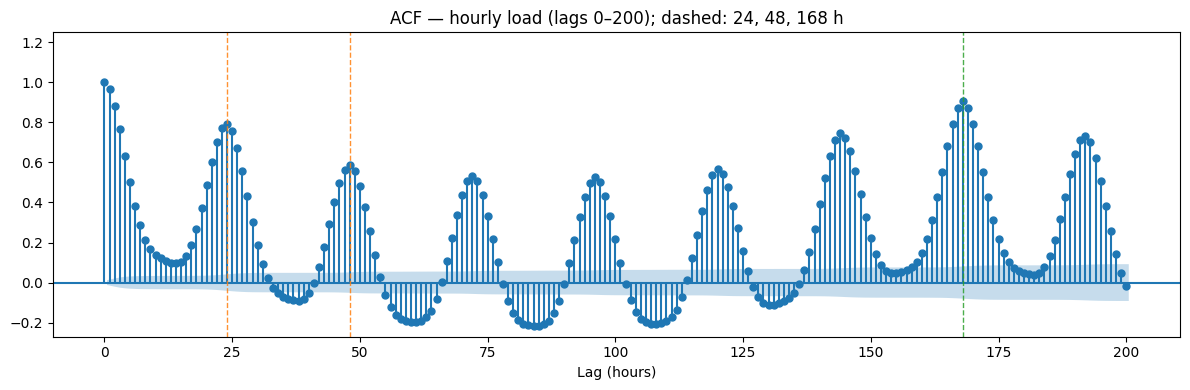

In [3]:
MAX_LAG = 200

fig, ax = plt.subplots(figsize=(12, 4))
plot_acf(hourly, lags=MAX_LAG, ax=ax, alpha=0.05, auto_ylims=True)
for lag, c in [(24, "C1"), (48, "C1"), (168, "C2")]:
    ax.axvline(lag, color=c, ls="--", lw=1, alpha=0.85)
ax.set_title(f"ACF — hourly load (lags 0–{MAX_LAG}); dashed: 24, 48, 168 h")
ax.set_xlabel("Lag (hours)")
plt.tight_layout()
plt.show()

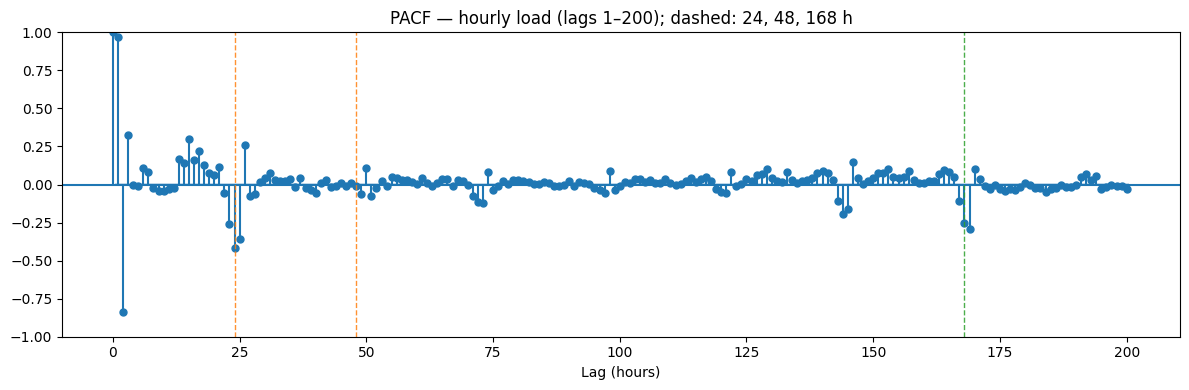

In [4]:
fig, ax = plt.subplots(figsize=(12, 4))
plot_pacf(hourly, lags=MAX_LAG, ax=ax, alpha=0.05, method="ywm")
for lag, c in [(24, "C1"), (48, "C1"), (168, "C2")]:
    ax.axvline(lag, color=c, ls="--", lw=1, alpha=0.85)
ax.set_title(f"PACF — hourly load (lags 1–{MAX_LAG}); dashed: 24, 48, 168 h")
ax.set_xlabel("Lag (hours)")
plt.tight_layout()
plt.show()